## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=5)

df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]]


/mnt/nvme1/saeid/experiments/5/logs.json


,end_to_end_s
count,9999.000000
mean,15.305849
std,29.156593
min,0.137091
50%,6.925368
90%,31.744685
99%,200.507191
max,248.785725


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,serving_pod,serving_node,applied_time_offset_s,client_to_router_s,router_queue_s,router_to_sidecar_s,sidecar_queue_s,vllm_compute_s,sidecar_post_s,sidecar_to_router_s,router_result_handler_s
0,6,43ec0ff33e094ea8a0adf0041c10309a,False,0.239583,0.195458,stop,450,3,453,vllm-qwen3-8b-b5c7c689d-fc8kz,None,NaN,-506.019871,-506.006764,0.001248,0.000559,0.196816,0.000010,0.005804,7.152557e-07
1,5,a586551cd27b4c679fd3842a5c67ba24,False,0.574298,0.529666,stop,268,23,291,vllm-qwen3-8b-b5c7c689d-hj2tg,None,NaN,-506.019695,-506.009211,0.000792,0.003015,0.531183,0.000016,0.006988,9.536743e-07
2,0,a63f766b853b4f85b10b5fa348a2c841,False,2.634990,2.580893,stop,354,132,486,vllm-qwen3-8b-b5c7c689d-pc6gp,None,NaN,-506.002146,-506.001625,0.000832,0.000773,2.582469,0.000013,0.010609,1.907349e-06
3,10,15ea82e69f1743e492dc49b8a0cdd344,False,0.192398,0.152364,stop,457,4,461,vllm-qwen3-8b-b5c7c689d-fc8kz,None,NaN,-506.019809,-506.011215,0.000732,0.002526,0.153962,0.000007,0.004988,1.192093e-06
4,8,93a6c67a527c4e47bcb2ce0812c96320,False,1.379981,1.338945,stop,511,61,572,vllm-qwen3-8b-b5c7c689d-fkf62,None,NaN,-506.019599,-506.009811,0.000926,0.001143,1.340391,0.000014,0.005754,1.907349e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,9874,3ea93fac062048ddbd6e5ba05c0d144c,False,190.736734,190.646538,length,366,8192,8558,vllm-qwen3-8b-b5c7c689d-pc6gp,None,NaN,-506.004237,-505.992868,0.000616,0.001363,190.648174,0.000009,0.005995,7.152557e-07
9995,9853,5b82d1a2406e4245a3d67b53f67f13d7,False,201.609587,201.501150,length,539,8192,8731,vllm-qwen3-8b-b5c7c689d-5qkxm,None,NaN,-506.004209,-505.999294,0.000869,0.000119,201.502927,0.000012,0.007568,7.152557e-07
9996,9946,91292cf7033f4c5fae777444551b56f8,False,187.774842,187.684263,length,337,8192,8529,vllm-qwen3-8b-b5c7c689d-pc6gp,None,NaN,-506.004160,-505.992543,0.000646,0.000940,187.685989,0.000010,0.006344,4.768372e-07
9997,9901,c6207818f2384083a47338eafda21201,False,201.734301,201.639923,length,725,8192,8917,vllm-qwen3-8b-b5c7c689d-5qkxm,None,NaN,-506.002703,-505.994793,0.000819,0.003870,201.642006,0.000010,0.008948,4.768372e-07


In [3]:
from experiment_analysis import experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison

series_ids = [35]

[21, 22, 23, 24]
/mnt/nvme1/saeid/experiments/21/logs.json
/mnt/nvme1/saeid/experiments/22/logs.json
/mnt/nvme1/saeid/experiments/23/logs.json
/mnt/nvme1/saeid/experiments/24/logs.json


[21, 22, 23, 24]
/mnt/nvme1/saeid/experiments/21/logs.json
[exp 21] corrected_requests=0/9999
/mnt/nvme1/saeid/experiments/22/logs.json
[exp 22] corrected_requests=0/10000
/mnt/nvme1/saeid/experiments/23/logs.json
[exp 23] corrected_requests=0/10000
/mnt/nvme1/saeid/experiments/24/logs.json
[exp 24] corrected_requests=0/10000

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 21:
  client_to_router_s          : -504.478 s
  router_queue_s              : -504.465 s
  router_to_sidecar_s         :    0.001 s
  sidecar_queue_s             :    0.001 s
  vllm_compute_s              :   14.434 s
  sidecar_post_s              :    0.000 s
  sidecar_to_router_s         :    0.005 s
  router_post_result_s        :      nan s
  SUM (components)            : -994.501 s

  Router post-result breakdown:
    router_result_handler_s   : 0.000001 s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:

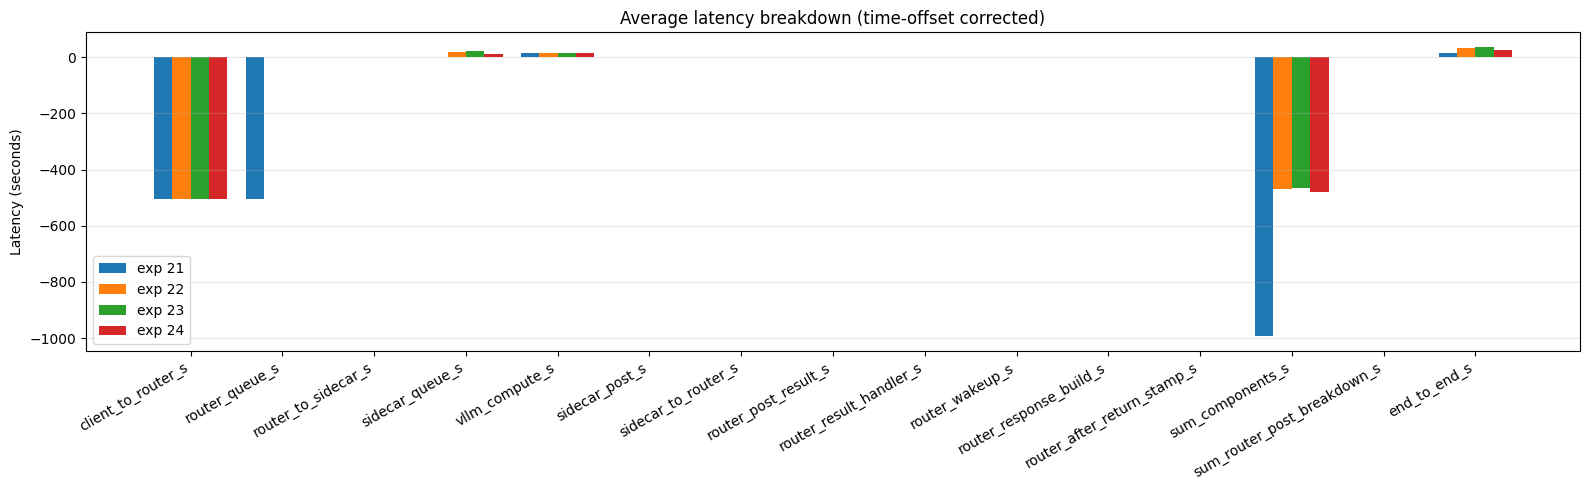

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]
print(experiments)
# ---------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]

e2e_col = "end_to_end_s"

plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")

for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]
print(experiments)

# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[21, 22, 23, 24]
/mnt/nvme1/saeid/experiments/21/logs.json
/mnt/nvme1/saeid/experiments/22/logs.json
/mnt/nvme1/saeid/experiments/23/logs.json
/mnt/nvme1/saeid/experiments/24/logs.json


,exp21_end_to_end_s,exp22_end_to_end_s,exp23_end_to_end_s,exp24_end_to_end_s
count,9999.000000,10000.000000,10000.000000,10000.000000
mean,14.481034,33.431753,36.900739,25.402990
std,27.359474,42.094022,64.181736,35.034365
min,0.143213,0.130901,0.137468,0.137604
50%,6.466234,18.385365,14.249707,13.969425
90%,31.073633,85.654935,86.333032,59.042474
99%,195.330044,209.368914,293.454382,201.290492
max,221.062043,325.552480,505.215962,291.198824


In [ ]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments (exclude first 20 entries) ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]
print(experiments)

# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)
    df = df.iloc[20:]

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison

/mnt/nvme1/saeid/experiments/5/logs.json


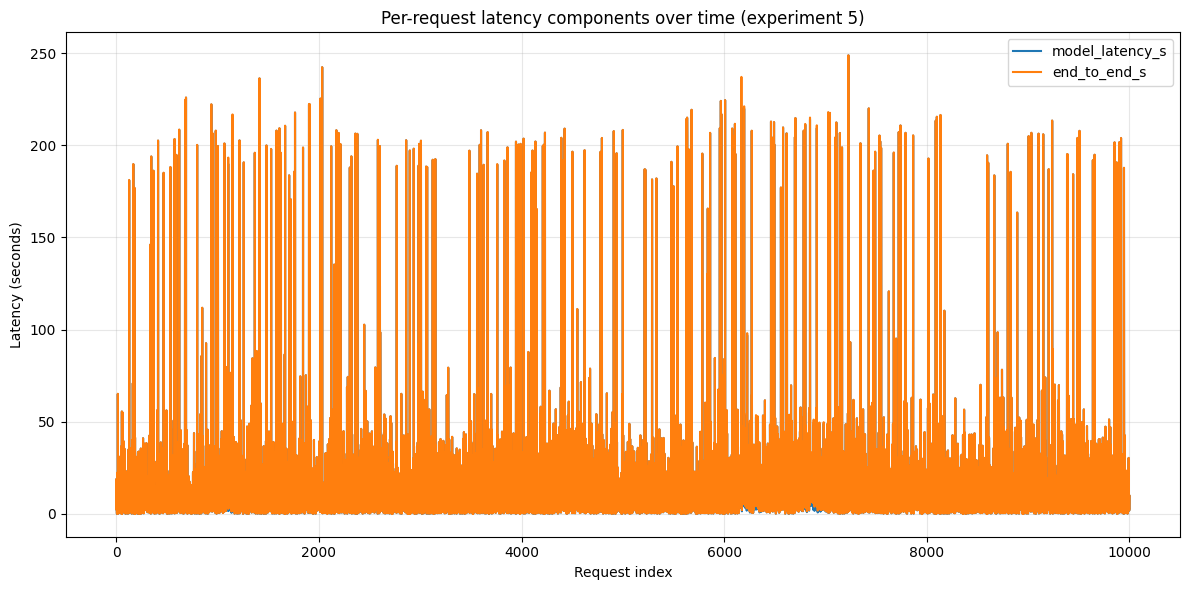

In [7]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 5
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(exp_id=exp_id).sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[21, 22, 23, 24]
/mnt/nvme1/saeid/experiments/21/logs.json
[exp 21] corrected_requests=0/9999
/mnt/nvme1/saeid/experiments/22/logs.json
[exp 22] corrected_requests=0/10000
/mnt/nvme1/saeid/experiments/23/logs.json
[exp 23] corrected_requests=0/10000
/mnt/nvme1/saeid/experiments/24/logs.json
[exp 24] corrected_requests=0/10000


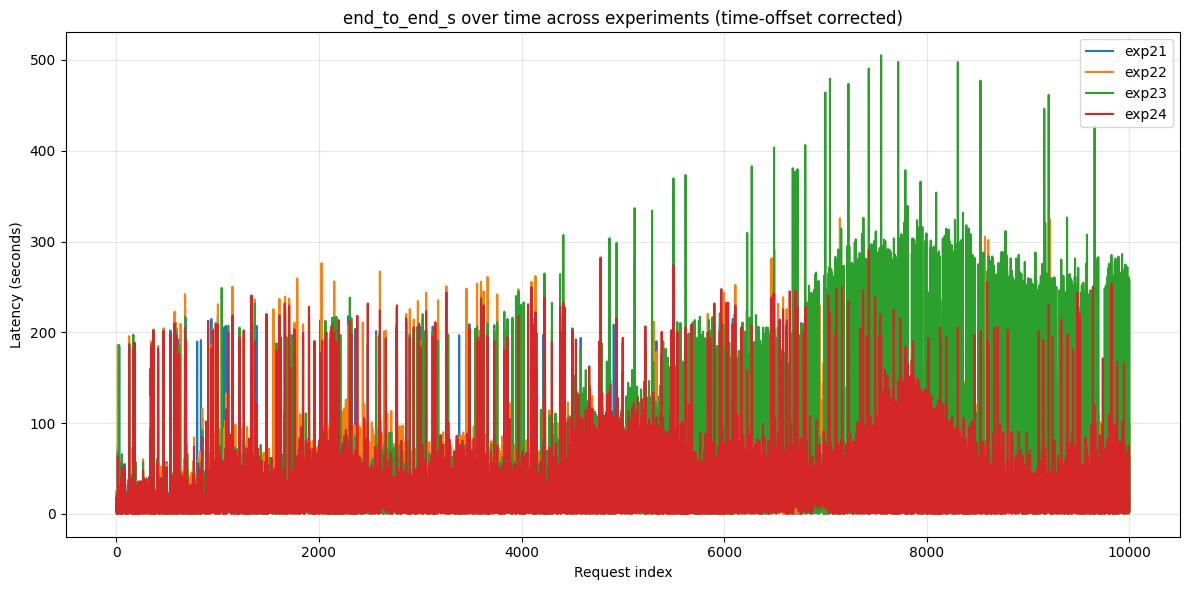

In [8]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
metric = "end_to_end_s"          # total client → router → server → client
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Throughput Metrics

In [9]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]
print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec", 
    # "gpu_kv_cache_usage_frac", # only available in GPU set up 
    # "cpu_kv_cache_usage_frac",
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[21, 22, 23, 24]


,exp21_gen_tokens_per_sec,exp21_ttft_seconds_avg,exp21_tpot_seconds_avg,exp22_gen_tokens_per_sec,exp22_ttft_seconds_avg,exp22_tpot_seconds_avg,exp23_gen_tokens_per_sec,exp23_ttft_seconds_avg,exp23_tpot_seconds_avg,exp24_gen_tokens_per_sec,exp24_ttft_seconds_avg,exp24_tpot_seconds_avg
count,808.000000,764.000000,807.000000,825.000000,793.000000,817.000000,860.000000,843.000000,846.000000,819.000000,783.000000,812.000000
mean,2095.992974,1.673869,0.022994,2130.334492,2.563032,0.023295,2010.690269,2.446249,0.023301,2094.059834,2.203182,0.023078
std,500.845686,1.348665,0.000927,534.829284,1.160941,0.001163,627.015037,1.313563,0.001073,532.126063,1.052109,0.001144
min,0.000000,0.125215,0.018468,0.000000,0.111571,0.017941,0.000000,0.111098,0.018478,0.000000,0.108480,0.017871
50%,2228.103448,1.512918,0.023222,2302.655172,2.480953,0.023535,2226.068966,2.313323,0.023437,2232.482759,2.149508,0.023213
90%,2441.700000,2.600149,0.023862,2451.641379,4.130282,0.024443,2423.658621,3.790674,0.024299,2417.186207,3.536507,0.024347
99%,2609.720690,3.728426,0.024319,2555.130542,5.440484,0.025538,2505.012759,7.829289,0.025568,2601.153103,4.768636,0.025374
max,2625.758621,32.957306,0.026632,2580.379310,5.743093,0.026027,2572.896552,9.651542,0.027196,2655.965517,6.003676,0.025919
SLO_COMPLIANCE_%,NaN,2.356021,100.000000,NaN,6.052963,100.000000,NaN,4.389087,100.000000,NaN,6.513410,100.000000


[21, 22, 23, 24]


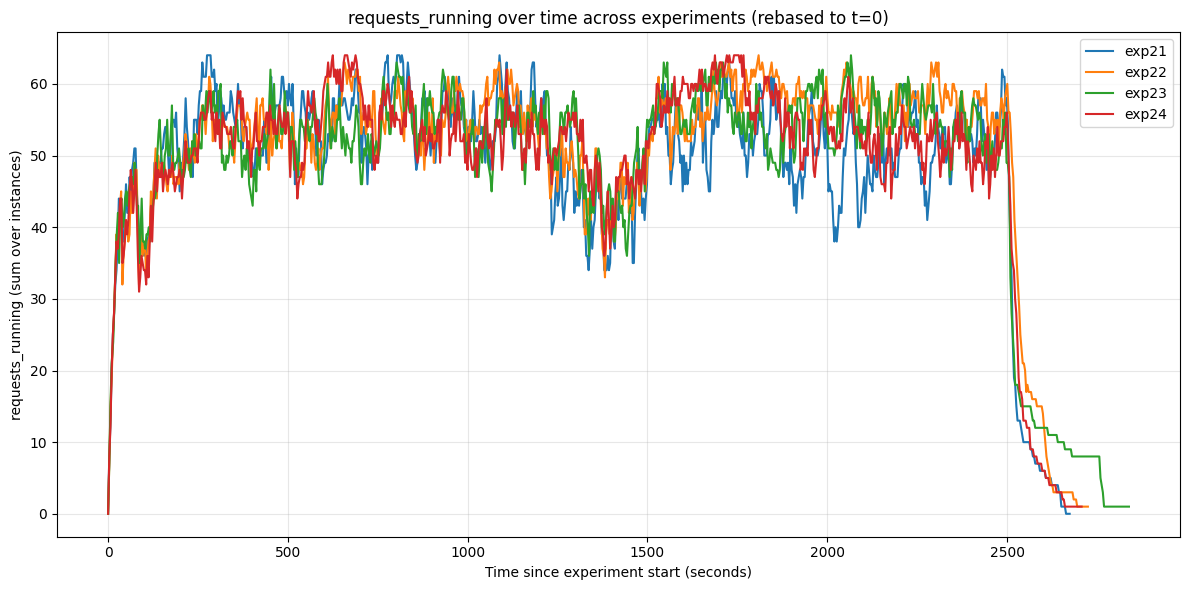

In [10]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "request_failure_per_sec"
# metric = "preemptions_per_sec"
# metric = "gpu_kv_cache_usage_frac"
# metric = "cpu_kv_cache_usage_frac"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

[21, 22, 23, 24]
/mnt/nvme1/saeid/experiments/21/logs.json
/mnt/nvme1/saeid/experiments/22/logs.json
/mnt/nvme1/saeid/experiments/23/logs.json
/mnt/nvme1/saeid/experiments/24/logs.json


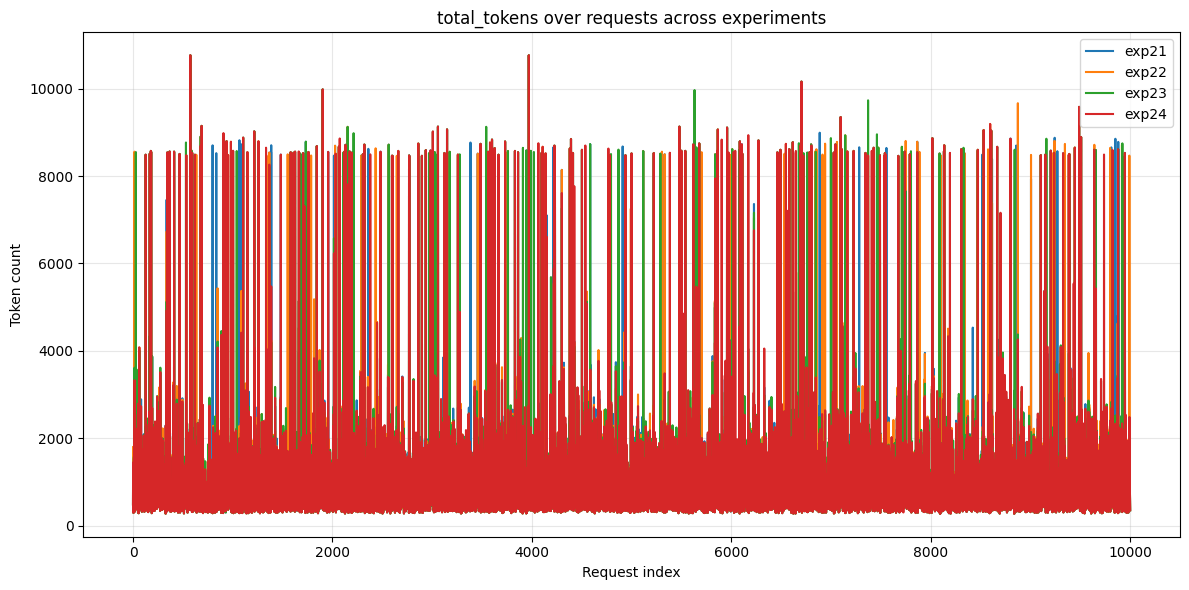

In [11]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [12]:
from experiment_analysis import load_experiment_latencies

experiments = [21, 22, 23, 24]

for exp_iexperiments in experiments:
    df = load_experiment_latencies(exp_id=exp_id)
    total = df["total_tokens"].sum()
    print(f"exp{exp_id}: {total} total tokens")

/mnt/nvme1/saeid/experiments/24/logs.json
exp24: 10064373 total tokens
/mnt/nvme1/saeid/experiments/24/logs.json
exp24: 10064373 total tokens
/mnt/nvme1/saeid/experiments/24/logs.json
exp24: 10064373 total tokens
/mnt/nvme1/saeid/experiments/24/logs.json
exp24: 10064373 total tokens


[21, 22, 23, 24]
/mnt/nvme1/saeid/experiments/21/logs.json
/mnt/nvme1/saeid/experiments/22/logs.json
/mnt/nvme1/saeid/experiments/23/logs.json
/mnt/nvme1/saeid/experiments/24/logs.json


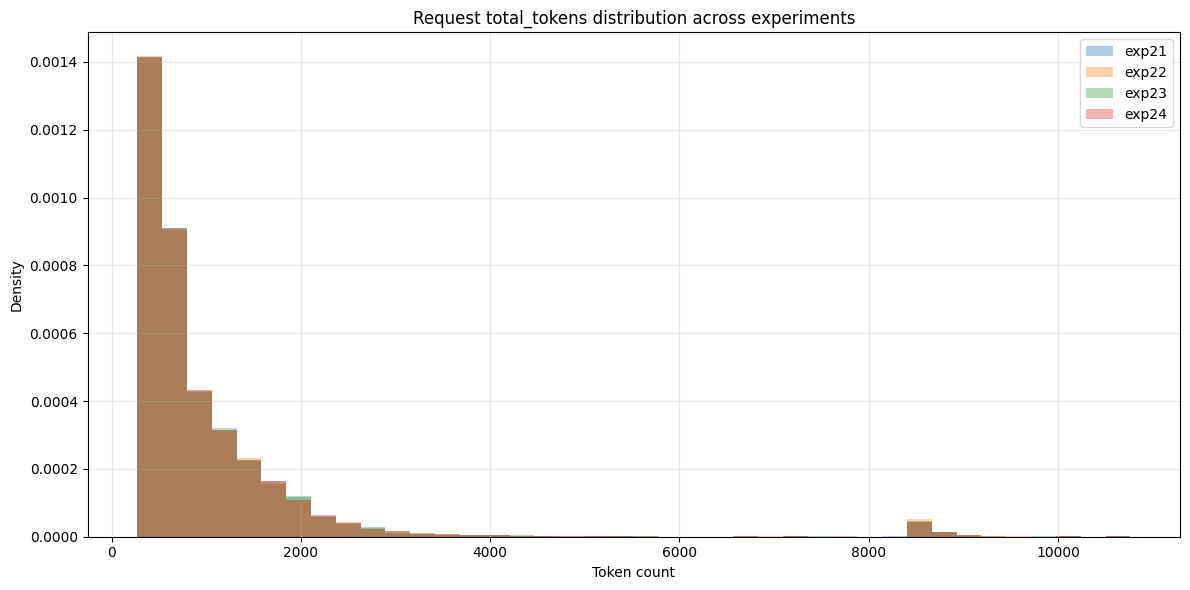

In [13]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
# metric = "completion_tokens"  # output length distribution
metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [14]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------


def count_requests(exp_id, experiments_root="/mnt/nvme1/saeid/experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


[21, 22, 23, 24]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,21,10000,9999,1,99.99,0.01
1,22,10000,10000,0,100.00,0.00
2,23,10000,10000,0,100.00,0.00
3,24,10000,10000,0,100.00,0.00


In [15]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================

METRICS_MODE = "all_new"  # <- change me

ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
]

MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}

if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")

SELECT_COLS = MODE_TO_COLS[METRICS_MODE]


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None


def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()


def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)

    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None

    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)

    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")


summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)

    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)

    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)

    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)

        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison


[21, 22, 23, 24]


,exp21_router_queue_length,exp21_router_admission_rps,exp21_router_outgoing_rps,exp21_sidecar_queue_length,exp21_sidecar_received_rps,exp21_sidecar_completed_rps,exp22_router_queue_length,exp22_router_admission_rps,exp22_router_outgoing_rps,exp22_sidecar_queue_length,...,exp23_router_outgoing_rps,exp23_sidecar_queue_length,exp23_sidecar_received_rps,exp23_sidecar_completed_rps,exp24_router_queue_length,exp24_router_admission_rps,exp24_router_outgoing_rps,exp24_sidecar_queue_length,exp24_sidecar_received_rps,exp24_sidecar_completed_rps
count,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,825.0,825.000000,825.000000,825.000000,...,860.000000,860.000000,860.000000,860.000000,819.0,819.000000,819.000000,819.000000,819.000000,819.000000
mean,0.001238,3.734148,0.549136,53.907178,3.731361,3.732544,0.0,3.664012,0.457526,122.889697,...,0.436194,129.777907,3.515944,3.514974,0.0,3.688124,0.461167,93.965812,3.686493,3.689845
std,0.035180,0.967781,0.242742,14.797101,0.973019,0.973005,0.0,1.083555,0.136795,52.585886,...,0.196732,68.074281,1.285365,1.191424,0.0,1.045161,0.132275,36.546769,1.049296,1.049113
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,4.000000,0.551724,57.000000,4.000000,3.965517,0.0,4.000000,0.482759,127.000000,...,0.448276,114.000000,4.000000,3.827586,0.0,4.000000,0.482759,93.000000,4.000000,3.896552
90%,0.000000,4.000000,0.862069,67.000000,4.034483,4.344828,0.0,4.000000,0.517241,194.600000,...,0.655172,234.100000,4.034483,4.448276,0.0,4.000000,0.517241,141.000000,4.034483,4.517241
99%,0.000000,4.000000,1.068966,75.930000,4.103448,4.687241,0.0,4.000000,0.517241,230.000000,...,0.827586,255.410000,4.103448,4.855862,0.0,4.034483,0.517241,161.000000,4.068966,5.137931
max,1.000000,4.275862,1.172414,80.000000,4.344828,4.931034,0.0,4.034483,0.517241,236.000000,...,0.931034,260.000000,4.103448,5.379310,0.0,4.034483,0.517241,165.000000,4.068966,5.655172


[21, 22, 23, 24]


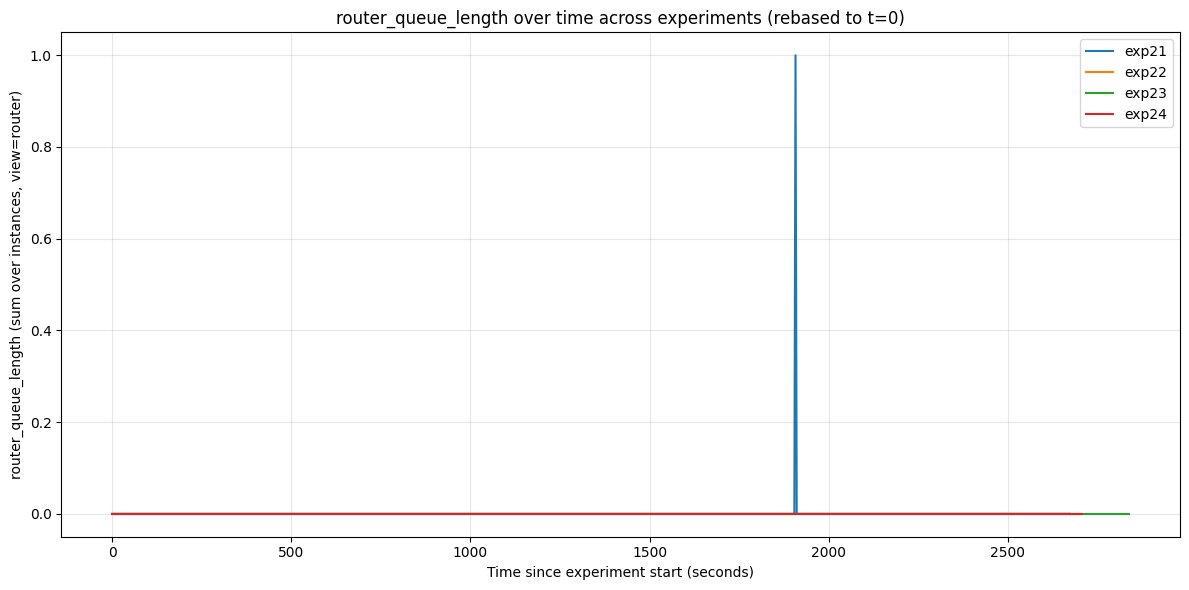

In [16]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"

# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[21, 22, 23, 24]


/tmp/ipykernel_1340842/1504331262.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(canonical_slots))


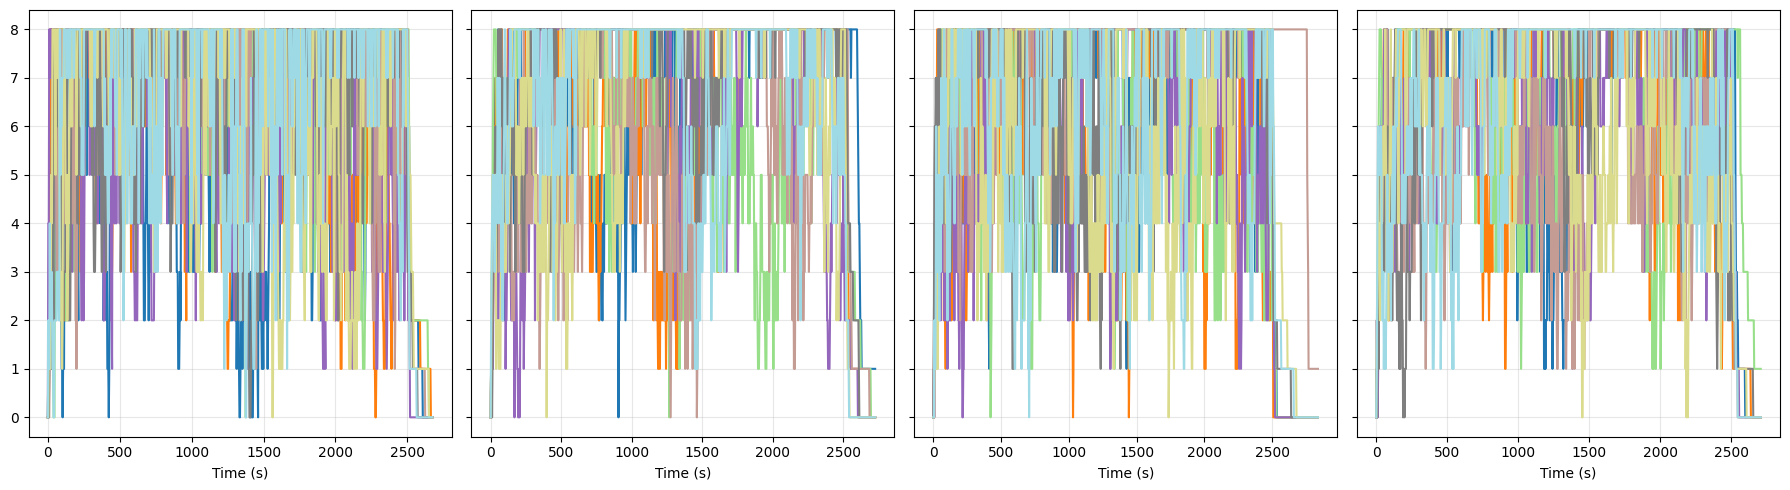

In [17]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [21, 22, 23, 24]
print(experiments)

# ============================================================
# Choose ONE metric
# ============================================================
# metric = "sidecar_queue_length"
metric = "requests_running"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = cm.get_cmap("tab20", len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
# plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()
